##### Copyright 2026 Google LLC.

In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://ai.google.dev/gemma/docs/diffusiongemma/inference-diffusiongemma-with-hf"><img src="https://ai.google.dev/static/site-assets/images/docs/notebook-site-button.png" height="32" width="32" />View on ai.google.dev</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/google-gemma/cookbook/blob/main/docs/diffusiongemma/inference-diffusiongemma-with-hf.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/google-gemma/cookbook/blob/main/docs/diffusiongemma/inference-diffusiongemma-with-hf.ipynb"><img src="https://www.kaggle.com/static/images/logos/kaggle-logo-transparent-300.png" height="32" width="70"/>Run in Kaggle</a>
  </td>
  <td>
    <a target="_blank" href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fgoogle-gemma%2Fcookbook%2Fmain%2Fdocs%2Fdiffusiongemma%2Finference-diffusiongemma-with-hf.ipynb"><img src="https://ai.google.dev/images/cloud-icon.svg" width="40" />Open in Vertex AI</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/google-gemma/cookbook/blob/main/docs/diffusiongemma/inference-diffusiongemma-with-hf.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
</table>

# Generate DiffusionGemma output with Hugging Face Transformers

DiffusionGemma is an experimental open model that explores text diffusion, an exceptionally fast approach to text generation. Based on the 26B (4B active) Mixture-of-Experts (MoE) Gemma 4 architecture, DiffusionGemma generates tokens using discrete diffusion.

Note: This notebook requires a GPU which has more than 60GB of memory such as NVIDIA G4 or NVIDIA H100.

## Install Python packages

Install the Hugging Face libraries required for running the DiffusionGemma model and making requests.

In [ ]:
# Install PyTorch & other libraries
!pip install torch accelerate

# Install the transformers library
!pip install "transformers>=5.11.0"

## Load Model

Use `transformers` library to load the model.

In [2]:
from transformers import DiffusionGemmaForBlockDiffusion, AutoProcessor

MODEL_ID = "google/diffusiongemma-26B-A4B-it"

model = DiffusionGemmaForBlockDiffusion.from_pretrained(
    MODEL_ID, dtype="auto", device_map="auto",
)
processor = AutoProcessor.from_pretrained(MODEL_ID)

config.json:   0%|          | 0.00/3.47k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/105k [00:00<?, ?B/s]

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1047 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/1.69k [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/17.5k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.74k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

Use a prompt template to structure your request. A prompt template allows you to specify input from specific roles, such as `user` or `model`, and is a required format for managing multi-turn chat interactions with Gemma models.

In [3]:
message = [
    {"role": "user", "content": "Why is the sky blue?"}
]

input_ids = processor.apply_chat_template(message, tokenize=True, add_generation_prompt=True, return_dict=True, return_tensors="pt").to(model.device)
output = model.generate(**input_ids, max_new_tokens=512)

text = processor.decode(output[0], skip_special_tokens=False)
print(text[0])

<bos><|turn>user
Why is the sky blue?<turn|>
<|turn>model
<|channel>thought
<channel|>The sky is blue due to a phenomenon called **Rayleigh scattering**.

Here is the step-by-step breakdown of how it works:

### 1. Sunlight is made of all colors
Although sunlight looks white to us, it is actually composed of all the colors of the rainbow (red, orange, yellow, green, blue, indigo, and violet). Each color travels as a wave with a different wavelength.

### 2. The atmosphere is an obstacle
The Earth’s atmosphere is filled with gases (mostly nitrogen and oxygen). When sunlight enters the atmosphere, it hits the gas molecules and scat in all directions.

### 3. Short waves scatter more
Different colors interact with the gas molecules differently based on their wavelength:
*   **Red and yellow light** have long, lazy waves. They pass through the atmosphere easily without hitting many molecules.
*   **Blue and violet light** have shorter, choppier waves. When these waves hit the gas molecules

Use `TextDiffusionStreamer` to see the intermediate state of diffusion process.

In [4]:
from transformers import TextDiffusionStreamer

streamer = TextDiffusionStreamer(tokenizer=processor.tokenizer)

message = [
    {"role": "user", "content": "Why is the sky blue?"}
]

input_ids = processor.apply_chat_template(message, tokenize=True, add_generation_prompt=True, return_dict=True, return_tensors="pt").to(model.device)
output = model.generate(**input_ids, max_new_tokens=512, streamer=streamer)

text = processor.decode(output[0], skip_special_tokens=False)
print("\n-- Final Output --")
print(text[0])

<bos><|turn>user
Why is the sky 7The sky is blue due to a a called ** **Ray called**,**.

 is is the the the the---stepstepstep:



 11... is Sunlight Sunlight of of
,
, white,,, it it it,, of of of of of of,,,,,,,,,,,,,,,,,,,,,,,,,,,..................... the. the the the the the, the the the the the the the the the the the the the the the the the the.. the the the................................... the.... the........ the.............. the. the........................... blue.... blue. blue blue. blue. blue blue blue. the blue blue blue blue blue87The sky is blue because of a phenomenon called **Rayleigh scattering**. 

Here is the stepby-stepstep of of it it:

### 1. Sunlight is made of of of colors
 sunlight sunlight sunlight looks white white white, is actually actually of of of the the the the (red,,,,,, green,,,,, violet violet Each light light travels travels with different different different..

###  ... Light Light













.
.
..
.******.**.............................

## System instructions

Use the `system` role to provide the system-level instructions.

In [5]:
message = [
    {"role": "system", "content": "Speak like a pirate."},
    {"role": "user", "content": "Why is the sky blue?"}
]

input_ids = processor.apply_chat_template(message, tokenize=True, add_generation_prompt=True, return_dict=True, return_tensors="pt").to(model.device)
output = model.generate(**input_ids, max_new_tokens=512)

text = processor.decode(output[0], skip_special_tokens=False)
print(text[0])

<bos><|turn>system
Speak like a pirate.<turn|>
<|turn>user
Why is the sky blue?<turn|>
<|turn>model
<|channel>thought
<channel|>Gather 'round, ye scurvy dogs, and listen close, as I tell ye the tale of why the heavens wear the color of the deep!

It all comes down to something called **Rayleigh scattering**. Ye see, the sun's light looks white to yer mortal eyes, but it’s actually a treasure chest full of every color in the rainbow—red, orange, yellow, green, blue, indigo, and violet.

When that sunlight hits our atmosphere, it crashes into the air molecules and tiny particles. The longer waves, like red and yellow, be brave and lazy; they sail right through like a mighty galleon on a calm sea.

But the blue light? Ah, the blue waves be short and choppy! When they hit the air, they get knocked about and smashed, scattered in every direction like a school of panicked fish fleein' from a shark. 

So, when ye look up from the deck, yer eyes be catchin' all that blue light that's been boun

## A single text inference with Thinking

To generate a response using the model's thinking capabilities, pass `enable_thinking=True`, the processor will insert the correct thinking tokens into the prompt, instructing the model to think before responding.

In [6]:
message = [
    {"role": "user", "content": "What is the water formula?"}
]

input_ids = processor.apply_chat_template(message, tokenize=True, add_generation_prompt=True, return_dict=True, return_tensors="pt", enable_thinking=True).to(model.device)
output = model.generate(**input_ids, max_new_tokens=512)

text = processor.decode(output[0], skip_special_tokens=False)
print(text[0])

<bos><|turn>system
<|think|>
<turn|>
<|turn>user
What is the water formula?<turn|>
<|turn>model
<|channel>thought
*   User asking: "What is the water formula?"
    *   Goal: Provide the chemical formula for water and explain what it means.

    *   Water is a compound made of hydrogen and oxygen.
    *   The formula is $H_2O$.

    *   Direct answer: $H_2O$.
    *   Explanation of components:
        *   $H_2$: Two atoms of hydrogen.
        *   $O$: One atom of oxygen.
<channel|>The chemical formula for water is **$H_2O$**.

This means that each molecule of water is made of:
*   **Two hydrogen atoms**
*   **One oxygen atom**<turn|><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad>

## Image understanding

The following example shows how to provide an image and ask question about it.

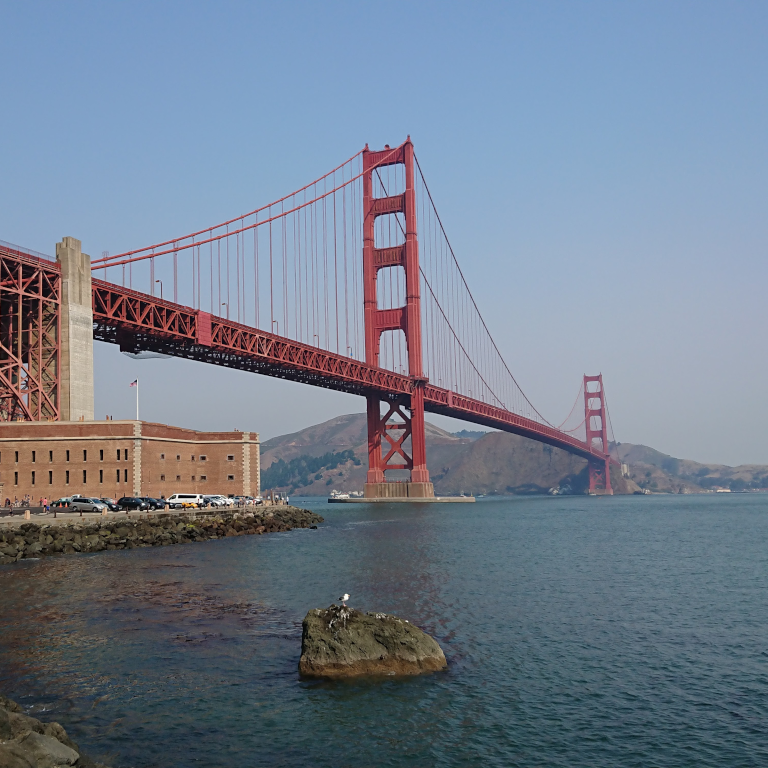

<bos><|turn>user
<|image><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|i

In [7]:
from PIL import Image
from IPython.display import display
import requests

img_url = "https://raw.githubusercontent.com/google-gemma/cookbook/refs/heads/main/apps/sample-data/GoldenGate.png"
input_image = Image.open(requests.get(img_url, stream=True).raw)
display(input_image)

message = [
    {
        "role": "user", "content": [
            {"type": "image", "url": img_url},
            {"type": "text", "text": "What is shown in this image?"}
        ]
    }
]

input_ids = processor.apply_chat_template(message, tokenize=True, add_generation_prompt=True, return_dict=True, return_tensors="pt").to(model.device)
output = model.generate(**input_ids, max_new_tokens=512)

text = processor.decode(output[0], skip_special_tokens=False)
print(text[0])

## Summary and next steps

In this guide, you learned how to use DiffusionGemma for various tasks. Check out [Diffusion in Text Generation Explained](https://ai.google.dev/gemma/docs/diffusiongemma/explained) to understand how model works in detail.